In [12]:
import pandas as pd

df = pd.read_csv('../data/sales.csv')

print(df.head())
print(df.info())
print(df.describe())


   order_id  order_date  product_id product_category   price  \
0         1  2022-04-13        2637            Books  128.75   
1         2  2023-03-12        2300          Fashion  302.60   
2         3  2022-09-28        3670           Sports  495.80   
3         4  2022-04-17        2522            Books  371.95   
4         5  2022-03-13        1717           Beauty  201.68   

   discount_percent  quantity_sold customer_region payment_method  rating  \
0                10              4   North America            UPI     3.5   
1                20              5            Asia    Credit Card     3.7   
2                20              2          Europe            UPI     4.4   
3                15              4     Middle East            UPI     5.0   
4                 0              4     Middle East            UPI     4.6   

   review_count  discounted_price  total_revenue  profit  
0           443            115.88         463.52  23.176  
1           475            242.08 

In [13]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
profit              0
dtype: int64

In [14]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [15]:
total_revenue = df['total_revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 32866573.74


In [16]:
top_categories = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
print(top_categories)

product_category
Beauty            5550624.97
Books             5484863.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Electronics       5470594.03
Sports            5407235.82
Name: total_revenue, dtype: float64


In [18]:
region_sales = df.groupby('customer_region')['total_revenue'].sum()
print(region_sales)

customer_region
Asia             8175199.83
Europe           8112311.57
Middle East      8301844.50
North America    8277217.84
Name: total_revenue, dtype: float64


In [19]:
df['month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('month')['total_revenue'].sum()
print(monthly_sales)

month
2022-01    1419751.89
2022-02    1266714.29
2022-03    1392585.42
2022-04    1371955.83
2022-05    1374779.57
2022-06    1352125.49
2022-07    1346089.18
2022-08    1449308.06
2022-09    1403967.06
2022-10    1334818.11
2022-11    1291100.05
2022-12    1386209.61
2023-01    1464174.99
2023-02    1238380.51
2023-03    1366418.41
2023-04    1307017.94
2023-05    1431398.77
2023-06    1394822.13
2023-07    1442176.66
2023-08    1396321.88
2023-09    1341007.86
2023-10    1425936.23
2023-11    1334328.47
2023-12    1335185.33
Freq: M, Name: total_revenue, dtype: float64


In [20]:
df['year'] = df['order_date'].dt.year
monthly_yearly = df.groupby(['year', 'month'])['total_revenue'].sum()
print(monthly_yearly)

year  month  
2022  2022-01    1419751.89
      2022-02    1266714.29
      2022-03    1392585.42
      2022-04    1371955.83
      2022-05    1374779.57
      2022-06    1352125.49
      2022-07    1346089.18
      2022-08    1449308.06
      2022-09    1403967.06
      2022-10    1334818.11
      2022-11    1291100.05
      2022-12    1386209.61
2023  2023-01    1464174.99
      2023-02    1238380.51
      2023-03    1366418.41
      2023-04    1307017.94
      2023-05    1431398.77
      2023-06    1394822.13
      2023-07    1442176.66
      2023-08    1396321.88
      2023-09    1341007.86
      2023-10    1425936.23
      2023-11    1334328.47
      2023-12    1335185.33
Name: total_revenue, dtype: float64


In [22]:
import matplotlib.pyplot as plt

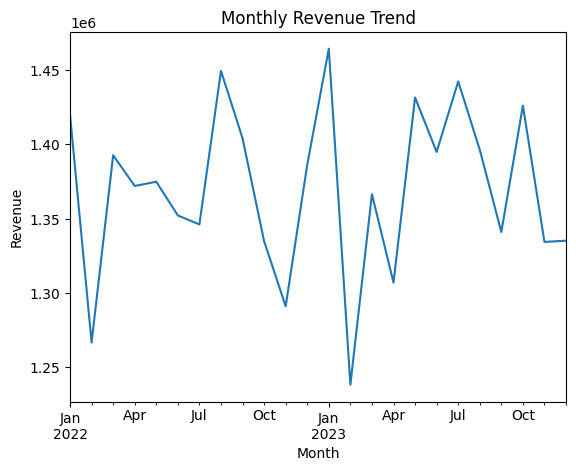

In [23]:
monthly_sales.plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

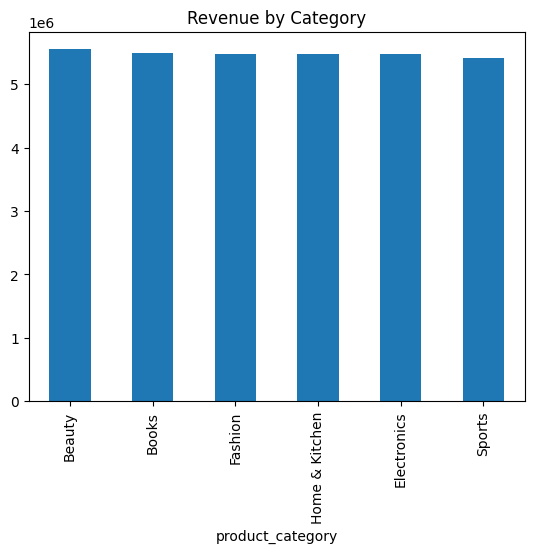

In [24]:
top_categories.plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

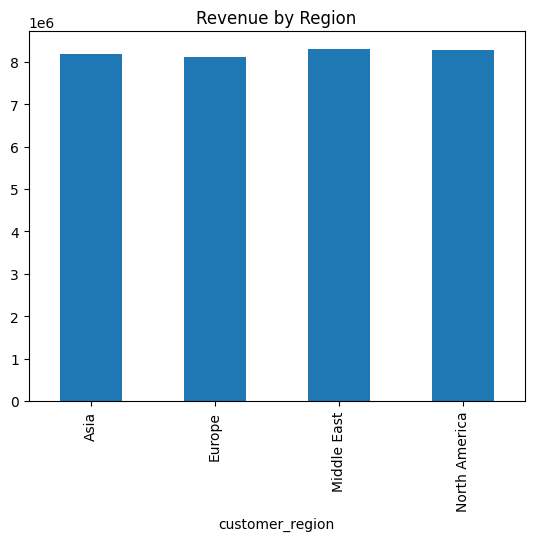

In [25]:
region_sales.plot(kind='bar')
plt.title("Revenue by Region")
plt.show()

In [26]:
import seaborn as sns
sns.set(style="whitegrid")

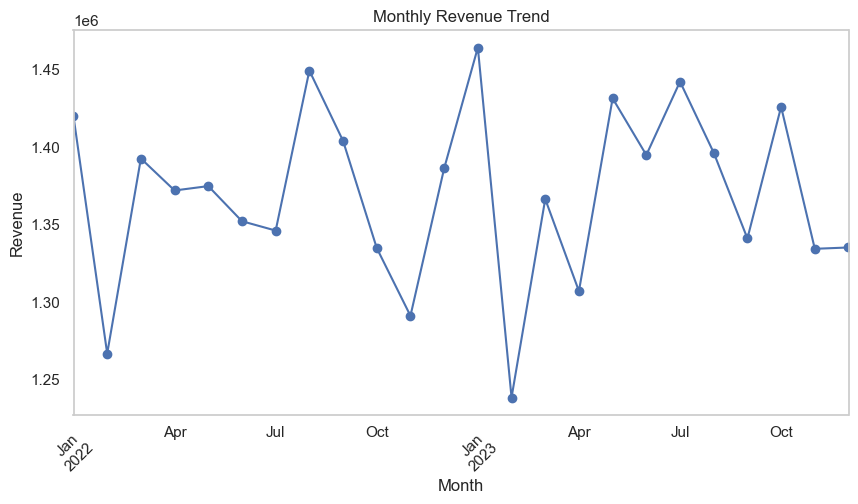

In [27]:
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.show()

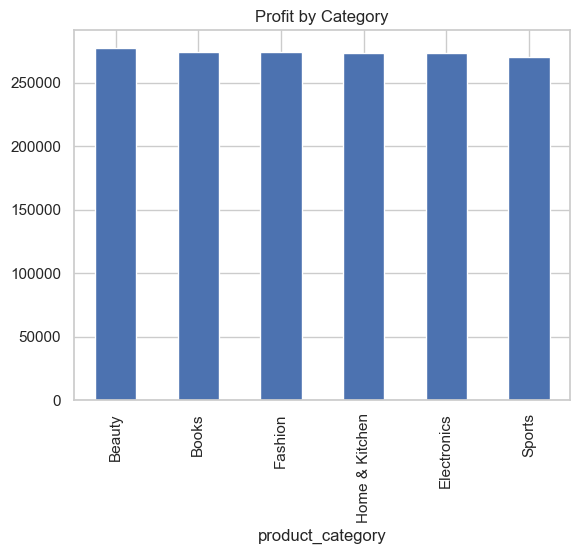

In [28]:
profit_by_category = df.groupby('product_category')['profit'].sum().sort_values(ascending=False)

profit_by_category.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

/var/folders/zp/k1zm8wfd31v1s829kq5m8wkr0000gn/T/ipykernel_79732/1212778164.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  efficiency = df.groupby('product_category').apply(


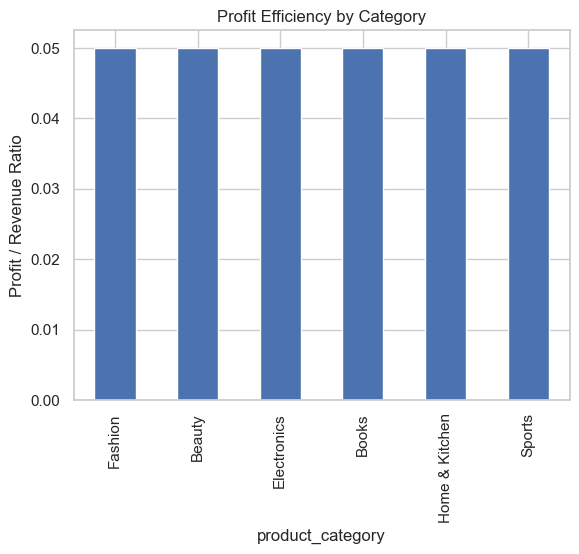

In [29]:
efficiency = df.groupby('product_category').apply(
    lambda x: x['profit'].sum() / x['total_revenue'].sum()
).sort_values(ascending=False)

efficiency.plot(kind='bar')
plt.title("Profit Efficiency by Category")
plt.ylabel("Profit / Revenue Ratio")
plt.show()